### Imports

In [ ]:
from torchmetrics.classification import (
    MultilabelAUROC,
    MultilabelAccuracy,
    MultilabelAveragePrecision,
    MultilabelF1Score,
    MultilabelPrecision,
    MultilabelRecall,
    MultilabelConfusionMatrix,
)
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score
import torch.nn.functional as F

### Synthetic data

In [ ]:
# real labels (multi-label)
target = torch.tensor([[1, 0, 1], [0, 1, 0], [1, 1, 0]])

# model predictions (prawdopodobieństwa)
preds = torch.tensor([[0.9, 0.2, 0.4], [0.3, 0.7, 0.4], [0.2, 0.2, 0.6]])

### Calculating metrics

In [ ]:
from typing import Optional


def calculate_metrics(target, preds, threshold=0.5):

    auroc = MultilabelAUROC(num_labels=3, average="macro")
    auroc_micro = MultilabelAUROC(num_labels=3, average="micro")
    accuracy = MultilabelAccuracy(num_labels=3, average="macro", threshold=threshold)
    accuracy_micro = MultilabelAccuracy(num_labels=3, average="micro", threshold=threshold)
    avg_precision = MultilabelAveragePrecision(num_labels=3, average="macro")
    avg_precision_micro = MultilabelAveragePrecision(num_labels=3, average="micro")
    f1_score = MultilabelF1Score(num_labels=3, average="macro", threshold=threshold)
    f1_score_micro = MultilabelF1Score(num_labels=3, average="micro", threshold=threshold)
    precision = MultilabelPrecision(num_labels=3, average="macro", threshold=threshold)
    precision_micro = MultilabelPrecision(num_labels=3, average="micro", threshold=threshold)
    recall = MultilabelRecall(num_labels=3, average="macro", threshold=threshold)
    recall_micro = MultilabelRecall(num_labels=3, average="micro", threshold=threshold)
    confusion_matrix = MultilabelConfusionMatrix(num_labels=3)

    metrics = {
        "AUROC": auroc(preds, target),
        "AUROC (Micro)": auroc_micro(preds, target),
        "Accuracy": accuracy(preds, target),
        "Accuracy (Micro)": accuracy_micro(preds, target),
        "Average Precision": avg_precision(preds, target),
        "Average Precision (Micro)": avg_precision_micro(preds, target),
        "F1 Score": f1_score(preds, target),
        "F1 Score (Micro)": f1_score_micro(preds, target),
        "Precision": precision(preds, target),
        "Precision (Micro)": precision_micro(preds, target),
        "Recall": recall(preds, target),
        "Recall (Micro)": recall_micro(preds, target),
        "Confusion Matrix": confusion_matrix(preds, target),
    }

    return metrics


def calculate_metrics_per_class(target, preds, num_labels=3, threshold=0.5):
    if isinstance(threshold, torch.Tensor):
        threshold = threshold.tolist()

    precision = MultilabelPrecision(num_labels=num_labels, threshold=threshold, average=None)
    recall = MultilabelRecall(num_labels=num_labels, threshold=threshold, average=None)
    f1 = MultilabelF1Score(num_labels=num_labels, threshold=threshold, average=None)
    accuracy = MultilabelAccuracy(num_labels=num_labels, threshold=threshold, average=None)

    return {
        "Precision per class": precision(preds, target),
        "Recall per class": recall(preds, target),
        "F1 per class": f1(preds, target),
        "Accuracy per class": accuracy(preds, target),
    }


def calculate_tp_fp_fn(target, preds, threshold=0.5):
    pred_bin = (preds > threshold).int()

    TP = ((pred_bin == 1) & (target == 1)).sum()
    TN = ((pred_bin == 0) & (target == 0)).sum()
    FP = ((pred_bin == 1) & (target == 0)).sum()
    FN = ((pred_bin == 0) & (target == 1)).sum()

    return TP, TN, FP, FN

In [ ]:
metrics = calculate_metrics(target, preds)
tp, tn, fp, fn = calculate_tp_fp_fn(target, preds)

print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}\n")

for metric_name, value in metrics.items():
    print(f"{metric_name}: {value}")

True Positives: 2
True Negatives: 3
False Positives: 1
False Negatives: 3

AUROC: 0.5
AUROC (Micro): 0.5750000476837158
Accuracy: 0.5555555820465088
Accuracy (Micro): 0.5555555820465088
Average Precision: 0.6666666865348816
Average Precision (Micro): 0.742222249507904
F1 Score: 0.4444444477558136
F1 Score (Micro): 0.5
Precision: 0.6666666865348816
Precision (Micro): 0.6666666865348816
Recall: 0.3333333432674408
Recall (Micro): 0.4000000059604645
Confusion Matrix: tensor([[[1, 0],
         [1, 1]],

        [[1, 0],
         [1, 1]],

        [[1, 1],
         [1, 0]]])


#### Conclusions
- MultilabelAccuracy is not a reliable metric in this case. With 14 possible diseases, even if one disease is predicted incorrectly, the overall accuracy can still remain high due to the large number of negative labels.

- Our goal is to maximize recall, so that the model becomes better at detecting diseases while tolerating small classification errors.

- The confusion matrix is a powerful tool for identifying which classes or cases are most difficult for the model

#### Per class

In [ ]:
metrics_per_class = calculate_metrics_per_class(target, preds)
for metric_name, values in metrics_per_class.items():
    print(f"{metric_name}: {values}")

Precision per class: tensor([1., 1., 0.])
Recall per class: tensor([0.5000, 0.5000, 0.0000])
F1 per class: tensor([0.6667, 0.6667, 0.0000])
Accuracy per class: tensor([0.6667, 0.6667, 0.3333])


In [ ]:
conf_matrix = metrics["Confusion Matrix"]
print("\nConfusion Matrix:")
for i in range(conf_matrix.shape[0]):
    print(
        f"Class {i}: TP={conf_matrix[i][0][0]}, FP={conf_matrix[i][0][1]}, FN={conf_matrix[i][1][0]}, TN={conf_matrix[i][1][1]}"
    )


Confusion Matrix:
Class 0: TP=1, FP=0, FN=1, TN=1
Class 1: TP=1, FP=0, FN=1, TN=1
Class 2: TP=1, FP=1, FN=1, TN=0


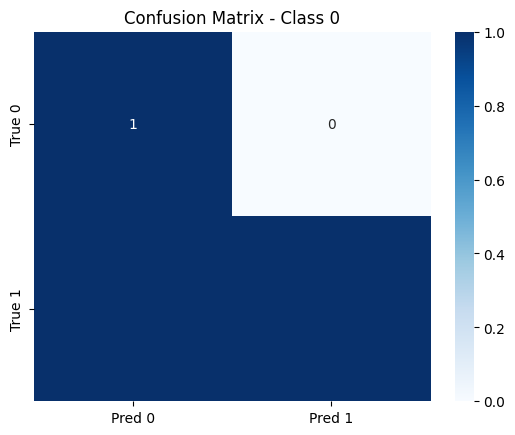

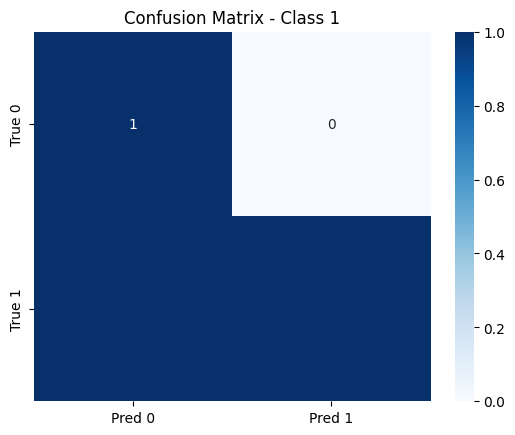

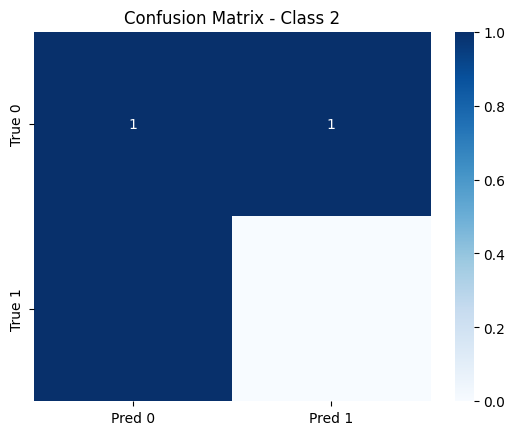

In [ ]:
for i, m in enumerate(conf_matrix):
    plt.figure()

    sns.heatmap(
        m.numpy(), annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"]
    )

    plt.title(f"Confusion Matrix - Class {i}")
    plt.show()

# Loss functions analysis

Classes

In [ ]:
targets = torch.tensor(
    [
        [1, 0, 0],
        [1, 0, 0],
        [1, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [1, 0, 1],
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
    ]
).float()

for i in range(targets.shape[1]):
    class_counts = targets[:, i].sum()
    print(f"Class {i} count: {int(class_counts.item())} / {targets.shape[0]}")

Class 0 count: 8 / 10
Class 1 count: 2 / 10
Class 2 count: 2 / 10


In [ ]:
print(targets.shape)

torch.Size([10, 3])


Predictions

In [ ]:
logits = torch.tensor(
    [
        [2.5, -1.2, -2.0],
        [2.2, -0.9, -1.8],
        [1.8, -1.1, -1.5],
        [2.0, -1.0, -1.7],
        [-0.5, 1.6, -1.0],
        [2.1, -0.8, -1.9],
        [1.4, -0.5, -0.2],
        [1.9, -1.1, -1.6],
        [-0.8, -0.7, -1.4],
        [2.3, 0, -1],
    ]
).float()

probs = torch.sigmoid(logits)

c0, c1, c2 = probs[:, 0], probs[:, 1], probs[:, 2]

print("Class 0 probabilities:", c0)
print("Class 1 probabilities:", c1)
print("Class 2 probabilities:", c2)

Class 0 probabilities: tensor([0.9241, 0.9002, 0.8581, 0.8808, 0.3775, 0.8909, 0.8022, 0.8699, 0.3100,
        0.9089])
Class 1 probabilities: tensor([0.2315, 0.2891, 0.2497, 0.2689, 0.8320, 0.3100, 0.3775, 0.2497, 0.3318,
        0.5000])
Class 2 probabilities: tensor([0.1192, 0.1419, 0.1824, 0.1545, 0.2689, 0.1301, 0.4502, 0.1680, 0.1978,
        0.2689])


### Threshold baseline

In [ ]:
threshold = 0.5
preds = (probs > threshold).float()

print("Predicted binary labels:\n", preds)
print(preds.shape)

Predicted binary labels:
 tensor([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 0.],
        [1., 0., 0.]])
torch.Size([10, 3])


In [ ]:
loss_bce = F.binary_cross_entropy_with_logits(logits, targets)

print("BCE:", loss_bce.item())

BCE: 0.353839248418808


### Label smoothing

In [ ]:
epsilon = 0.1

targets_smoothed = targets * (1 - epsilon) + epsilon * 0.5

loss_ls = F.binary_cross_entropy_with_logits(logits, targets_smoothed)

print("BCE + label smoothing:", loss_ls.item())

BCE + label smoothing: 0.4123392701148987


### Logit adjusment

In [ ]:
class_freq = targets.mean(dim=0)

logit_adj = torch.log(class_freq + 1e-8)

adjusted_logits = logits - logit_adj

loss_la = F.binary_cross_entropy_with_logits(adjusted_logits, targets)

print("BCE + logit adjustment:", loss_la.item())

BCE + logit adjustment: 0.6232039332389832


### ASL

In [ ]:
class ASL(torch.nn.Module):
    def __init__(self, gamma_pos=0, gamma_neg=4, clip=0.05):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        if self.clip:
            probs = torch.clamp(probs - self.clip, min=0)

        pos_loss = targets * torch.log(probs + 1e-8)
        neg_loss = (1 - targets) * torch.log(1 - probs + 1e-8)

        pos_weight = (1 - probs) ** self.gamma_pos
        neg_weight = probs**self.gamma_neg

        loss = -(pos_weight * pos_loss + neg_weight * neg_loss)

        return loss.mean()

In [ ]:
criterion = ASL()

loss_asl = criterion(logits, targets)

print("ASL:", loss_asl.item())

ASL: 0.20766374468803406


### ASL + label smoothing + logits adjusment

In [ ]:
targets_smoothed = targets * (1 - epsilon) + epsilon * 0.5

adjusted_logits = logits - logit_adj

loss_combo = criterion(adjusted_logits, targets_smoothed)

print("ASL + smoothing + logit adjustment:", loss_combo.item())

ASL + smoothing + logit adjustment: 0.1943255215883255


As shown in the example, different methods compute the loss in different ways. It is difficult to determine which method is superior based solely on synthetic data; however, such experiments can still provide useful insights into the training process

# Threshold finetuning

In [ ]:
best_thresholds_f1 = []
best_thresholds_recall = []
best_thresholds_precision = []

for c in range(3):
    best_f1 = -1
    best_f1_t = 0.5

    best_recall = -1
    best_recall_t = 0.5

    best_precision = -1
    best_precision_t = 0.5

    for t in np.linspace(0, 1, 50):
        preds_c = (probs[:, c] > t).int().cpu().numpy()
        targets_c = targets[:, c].int().cpu().numpy()

        f1 = f1_score(targets_c, preds_c, zero_division=0)
        recall = recall_score(targets_c, preds_c, zero_division=0)
        precision = precision_score(targets_c, preds_c, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_f1_t = t

        if recall > best_recall:
            best_recall = recall
            best_recall_t = t

        if precision > best_precision:
            best_precision = precision
            best_precision_t = t

    best_thresholds_f1.append(best_f1_t)
    best_thresholds_recall.append(best_recall_t)
    best_thresholds_precision.append(best_precision_t)

print("Best thresholds (F1):", best_thresholds_f1)
print("Best thresholds (Recall):", best_thresholds_recall)
print("Best thresholds (Precision):", best_thresholds_precision)

Best thresholds (F1): [np.float64(0.3877551020408163), np.float64(0.5102040816326531), np.float64(0.18367346938775508)]
Best thresholds (Recall): [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Best thresholds (Precision): [np.float64(0.3877551020408163), np.float64(0.5102040816326531), np.float64(0.2857142857142857)]


In [ ]:
def calculate_metrics_per_class(targets, probs, thresholds):
    if not torch.is_tensor(thresholds):
        thresholds = torch.tensor(thresholds, dtype=probs.dtype, device=probs.device)

    preds = (probs > thresholds).int()

    targets_np = targets.int().cpu().numpy()
    preds_np = preds.cpu().numpy()

    metrics = {
        "recall": recall_score(targets_np, preds_np, average=None, zero_division=0),
        "precision": precision_score(targets_np, preds_np, average=None, zero_division=0),
        "f1": f1_score(targets_np, preds_np, average=None, zero_division=0),
    }

    return metrics, preds

In [ ]:
# Base threshold = 0.5
base_thresholds = [0.5] * 3
metrics_base, preds_base = calculate_metrics_per_class(targets, probs, base_thresholds)

print("\nMetrics with constant threshold (0.5):")
for metric_name, values in metrics_base.items():
    print(f"{metric_name}: {values}")

# Thresholds optimized for F1
metrics_f1_opt, preds_f1_opt = calculate_metrics_per_class(targets, probs, best_thresholds_f1)

print("\nMetrics with thresholds optimized for F1:")
for metric_name, values in metrics_f1_opt.items():
    print(f"{metric_name}: {values}")

# Thresholds optimized for Recall
metrics_recall_opt, preds_recall_opt = calculate_metrics_per_class(targets, probs, best_thresholds_recall)

print("\nMetrics with thresholds optimized for Recall:")
for metric_name, values in metrics_recall_opt.items():
    print(f"{metric_name}: {values}")

# Thresholds optimized for Precision
metrics_precision_opt, preds_precision_opt = calculate_metrics_per_class(targets, probs, best_thresholds_precision)

print("\nMetrics with thresholds optimized for Precision:")
for metric_name, values in metrics_precision_opt.items():
    print(f"{metric_name}: {values}")


Metrics with constant threshold (0.5):
recall: [1.  0.5 0. ]
precision: [1. 1. 0.]
f1: [1.         0.66666667 0.        ]

Metrics with thresholds optimized for F1:
recall: [1.  0.5 1. ]
precision: [1.  1.  0.5]
f1: [1.         0.66666667 0.66666667]

Metrics with thresholds optimized for Recall:
recall: [1. 1. 1.]
precision: [0.8 0.2 0.2]
f1: [0.88888889 0.33333333 0.33333333]

Metrics with thresholds optimized for Precision:
recall: [1.  0.5 0.5]
precision: [1. 1. 1.]
f1: [1.         0.66666667 0.66666667]
